Step 1:Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style='whitegrid',palette='Set2')
plt.rcParams['figure.figsize']=(10,5)
plt.rcParams['font.size']=12

Step 2:Load a Dataset

In [3]:
df = sns.load_dataset('titanic')

print(f'Dataset shape:{df.shape[0]}rows x {df.shape[1]}columns\n')
df.head()

Dataset shape:891rows x 15columns



,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Step 3:Visualization types

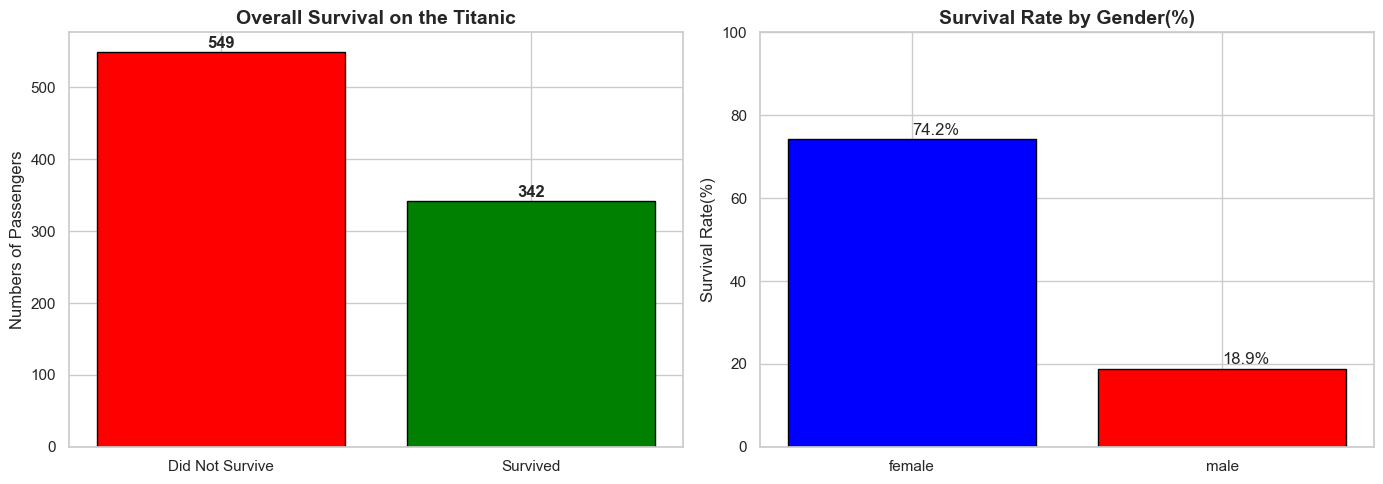

 Insight: only ~38% of passanger servived overall


In [8]:
import matplotlib.pyplot as plt
fig,axes=plt.subplots(1,2,figsize=(14,5))
survival_counts=df['survived'].value_counts()
axes[0].bar(
    ['Did Not Survive','Survived'],
    survival_counts.values,
    color=['red','green'],
    edgecolor='black'
)

axes[0].set_title('Overall Survival on the Titanic',fontsize=14,fontweight='bold')
axes[0].set_ylabel('Numbers of Passengers')

for i,v in enumerate(survival_counts.values):
    axes[0].text(i,v+5,str(v),ha='center',fontweight='bold')

#Chart 2
gender_survival=df.groupby('sex')['survived'].mean()*100
axes[1].bar(
    gender_survival.index,
    gender_survival.values,
    color=['blue','red'],
    edgecolor='black'
)

axes[1].set_title('Survival Rate by Gender(%)',fontsize=14,fontweight='bold')
axes[1].set_ylabel('Survival Rate(%)')
axes[1].set_ylim(0,100)   

for i,v in enumerate(gender_survival.values):
    axes[1].text(i,v+1,f'{v:.1f}%')

plt.tight_layout()
plt.show()

print(" Insight: only ~38% of passanger servived overall")

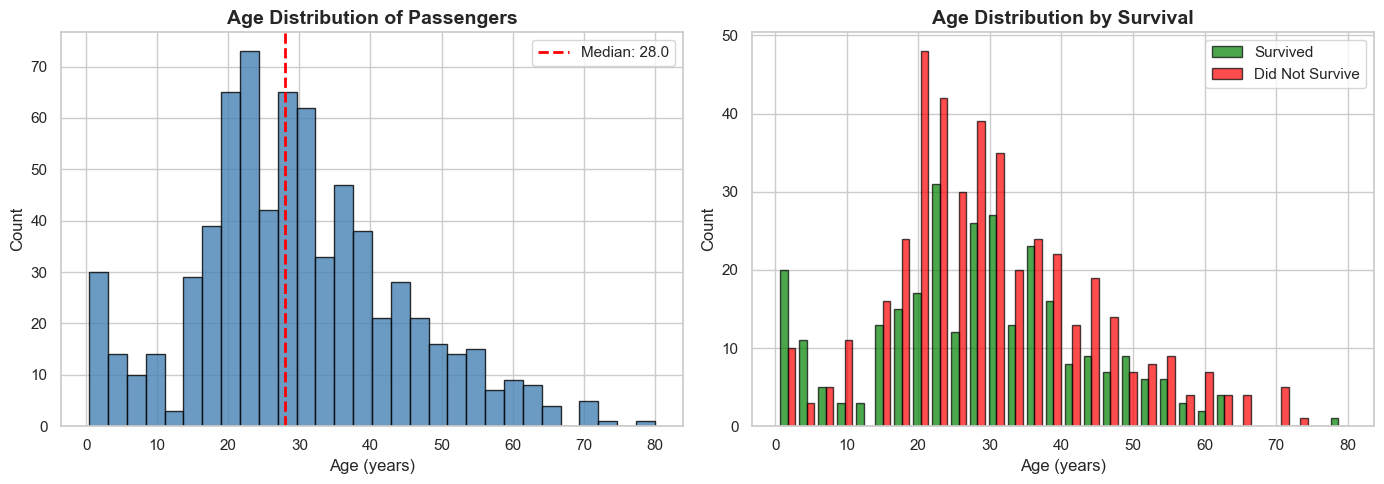

In [17]:
# Age distribution of passengers
fig, axes = plt.subplots(1,2, figsize=(14,5))

# Histogram of all ages
axes[0].hist(df['age'].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(df['age'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {df["age"].median()}')
axes[0].set_title('Age Distribution of Passengers', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Histogram of age by survival
survived_age = df[df['survived'] == 1]['age'].dropna()
not_survived_age = df[df['survived'] == 0]['age'].dropna()

axes[1].hist([survived_age, not_survived_age], bins=30, color=['green','red'], edgecolor='black', alpha=0.7, label=['Survived','Did Not Survive'])
axes[1].set_title('Age Distribution by Survival', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

/var/folders/nb/_rv6f3v52rq4wx3ktv25ltvr0000gn/T/ipykernel_68929/3742064189.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='survived', y='fare', data=df, palette=['red','green'], ax=axes[0])
/var/folders/nb/_rv6f3v52rq4wx3ktv25ltvr0000gn/T/ipykernel_68929/3742064189.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Did Not Survive','Survived'])
/var/folders/nb/_rv6f3v52rq4wx3ktv25ltvr0000gn/T/ipykernel_68929/3742064189.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fare_survival_rate = df.groupby('fare_bin')['survived'].mean()

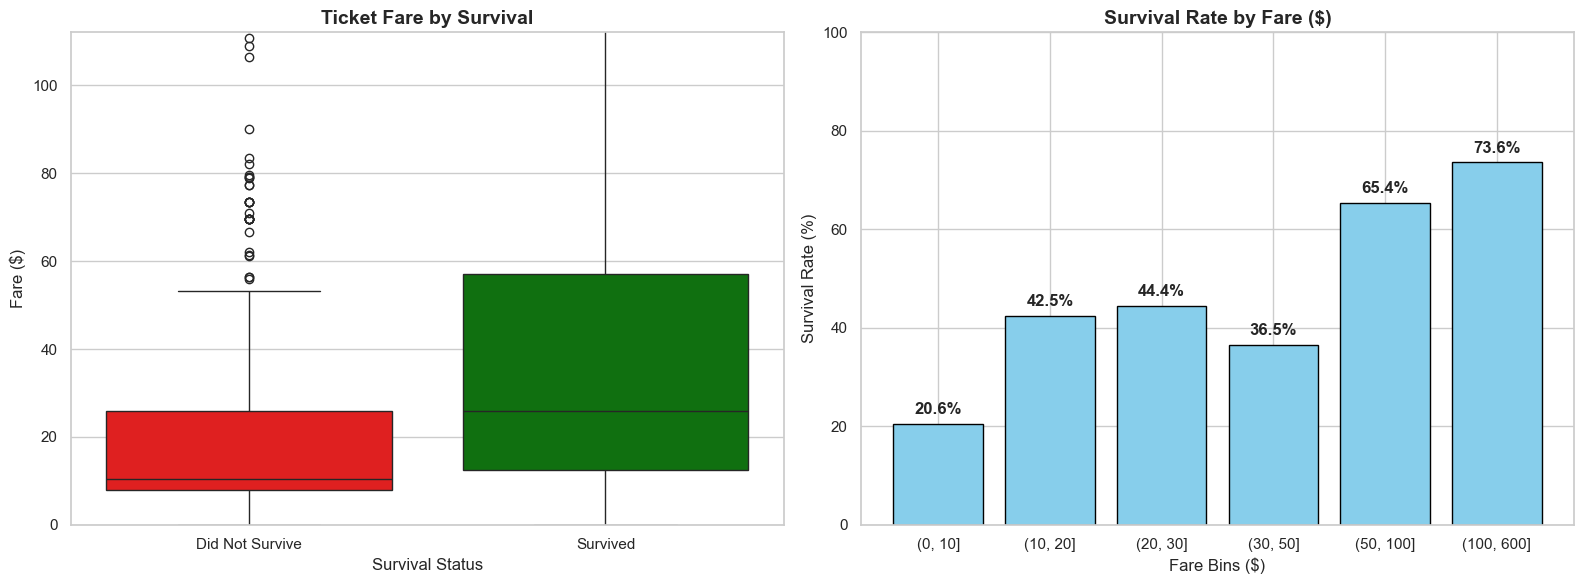

In [19]:

fig, axes = plt.subplots(1,2, figsize=(16,6))


sns.boxplot(x='survived', y='fare', data=df, palette=['red','green'], ax=axes[0])
axes[0].set_xticklabels(['Did Not Survive','Survived'])
axes[0].set_title('Ticket Fare by Survival', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Fare ($)')
axes[0].set_xlabel('Survival Status')
axes[0].set_ylim(0, df['fare'].quantile(0.95)) 

fare_bins = [0, 10, 20, 30, 50, 100, 600]
df['fare_bin'] = pd.cut(df['fare'], bins=fare_bins)

fare_survival_rate = df.groupby('fare_bin')['survived'].mean() * 100

axes[1].bar(fare_survival_rate.index.astype(str), fare_survival_rate.values, color='skyblue', edgecolor='black')
axes[1].set_title('Survival Rate by Fare ($)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fare Bins ($)')
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0,100)

for i, v in enumerate(fare_survival_rate.values):
    axes[1].text(i, v+2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()